## Intro

The goal of the following tutorial will be **building a convolutional neural network from scratch**. We'll revise the basic components of a CNN and then create one from scratch.

Source: https://d2l.ai/chapter_convolutional-neural-networks/index.html

Once trained, we'll see how libraries such as **pytorch lightning and weigths and biases** can help in simplifying and scaling the training process.

Finally, we'll briefly discuss **the basics of nn optimization**, as seen in https://github.com/google-research/tuning_playbook

In [1]:
# let's install the required packages for this tutorial first

!pip install d2l==1.0.3
!pip install pytorch-lightning
!pip install wandb
!pip install datasets

  Using cached requests-2.31.0-py3-none-any.whl.metadata (4.6 kB)
Using cached requests-2.31.0-py3-none-any.whl (62 kB)
  Attempting uninstall: requests
    Found existing installation: requests 2.32.3
    Uninstalling requests-2.32.3:
      Successfully uninstalled requests-2.32.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 1.19.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
datasets 3.0.1 requires requests>=2.32.2, but you have requests 2.31.0 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.3, but you have requests 2.31.0 which is incompatible.
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
Using cached requests-2.32.3-py3-none-any.whl (64 kB)
  Attempting uninstall: requests
    Found exist

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from d2l import torch as d2l

## Convolution Basics

This section will discuss implementation of the basic convolution operations and the most popular convolutional layers **from scratch**.

Let's start.

### Cross correlation

Convolutional layers combine an input tensor
and a kernel tensor to produce an output tensor through a (**cross-correlation operation.**)

Let's ignore **channels** for now and see how this works
with a simple example.

We have an input tensor of shape (1x3x3) and a (2x2) kernel.
The shape of the *kernel window* (or *convolution window*)
is given by the height and width of the kernel
(here it is $2 \times 2$).

![](http://d2l.ai/_images/correlation.svg)

We begin with the convolution window positioned
at the **upper-left corner** of the input tensor
and slide it across the input tensor,
both from left to right and top to bottom.
When the convolution window slides to a certain position,
the input subtensor contained in that window
and the kernel tensor are multiplied **elementwise**
and the resulting tensor is summed up
yielding a single scalar value.
This result gives the value of the output tensor
at the corresponding location.

The formula for the output size is given by the input size $n_\textrm{h} \times n_\textrm{w}$ minus the size of the convolution kernel $k_\textrm{h} \times k_\textrm{w}$:

$$(n_\textrm{h}-k_\textrm{h}+1) \times (n_\textrm{w}-k_\textrm{w}+1) \\ (3-2+1) \times (3-2+1)=2 $$

What if we wanted to further reduce the size of the image or simply keep it the same?

<details>
In the subsequent sections, we'll see the concepts of:
  <ul>
    <li> <b> padding </b> </li>
    <li> <b> stride </b> </li>
  </ul>
</details>

Let's try to implement the cross correlation operation from scratch.


In [3]:
def corr2d(X, K):
  """Compute 2D cross-correlation."""
  h, w = K.shape
  Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))

  for i in range(Y.shape[0]):
    for j in range(Y.shape[1]):
      Y[i, j] = (X[i:i + h, j:j + w] * K).sum()
  return Y

In [4]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
corr2d(X, K)

tensor([[19., 25.],
        [37., 43.]])

### Basic convolutional layer

A convolutional layer cross-correlates the input and kernel
and adds a scalar bias to produce an output.
The two parameters of a convolutional layer
are the kernel and the scalar bias.
When training models based on convolutional layers,
we typically initialize the kernels randomly,
just as we would with a fully connected layer.

We'll now implement a two-dimensional convolutional layer,
based on the `corr2d` function defined above.
In the `__init__` constructor method,
we declare `weight` and `bias` as the two model parameters.
The forward propagation method
calls the `corr2d` function and adds the bias.

In [5]:
class Conv2D(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return corr2d(x, self.weight) + self.bias

In
$h \times w$ convolution
or an $h \times w$ convolution kernel,
the height and width of the convolution kernel are $h$ and $w$, respectively.
We also refer to
a convolutional layer with an $h \times w$
convolution kernel simply as an $h \times w$ convolutional layer, e.g. a (3x3) convolutional layer.

#### Edge-detecting kernel

Let's see how we can learn (approximately) a **kernel to detected edges** in black and white images. As you have already seen, designing kernels for "easy" tasks (such as horizontal/vertical edge detection in b&w images) is easy. For **more complicated tasks**, it's a **good idea to learn our kernels, in order to generalize** over a vast set of training images.

If you think about it, it might be **impossible to specify
precisely** what each filter should be doing manually for very large convolutional networks (edges, objects, then what?).

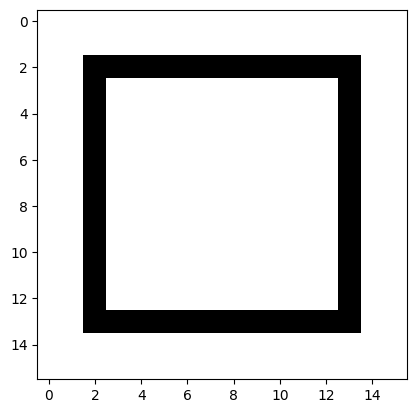

In [6]:
X = torch.ones((16,16))
# let's draw a black rectangle in the middle
X[2:3, 2:14] = 0
X[13:14, 2:14] = 0
X[2:14, 2:3] = 0
X[2:14, 13:14] = 0

plt.show(d2l.plt.imshow(X, cmap='gray'))

tensor([[ 1.,  2.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  2.,  1.],
        [ 1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.],
        [ 0., -1., -2., -3., -3., -3., -3., -3., -3., -3., -3., -2., -1.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  1.,  2.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  2.,  1.,  0.],
        [-1., -1., -1.,  0.,  0.,  0.,  

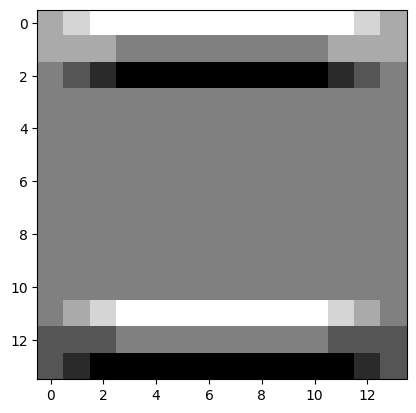

In [7]:
# let's now define a simple kernel to detect horizontal edges
# we'll use the Prewitt operator: https://en.wikipedia.org/wiki/Prewitt_operator
# it detects variation in intensity over the Y axis
# in our case, we expect to see a variation on the vertical edges (going from black to white)
# and the two corners (from white to black line)

# notice anything weird here?
K = torch.tensor([
  [1,  1,  1],
  [0,  0,  0],
  [-1,  -1, -1]
])

Y = corr2d(X, K) #using the formula seen before, can you predict the shape of Y?

print(Y)
plt.show(d2l.plt.imshow(Y, cmap='gray'))

In [8]:
# let's try to learn the kernel now, using the target image as a ground truth

# construct a 3x3 convolutional layer
# for the sake of simplicity, we ignore the bias here
# we have 1 input channel for b&w
conv2d = nn.LazyConv2d(1, kernel_size=(3,3), bias=False)

# let's reshape our image and the gt into batches
X = X.reshape((1, 1, 16, 16))
Y = Y.reshape((1, 1, 14, 14))
lr = 1e-4  # Learning rate

for i in range(250):
    Y_hat = conv2d(X)
    l = (Y_hat - Y) ** 2
    conv2d.zero_grad()
    l.sum().backward()
    # Update the kernel
    conv2d.weight.data -= lr * conv2d.weight.grad #ignore the error, this is dl2ai custom library
    if (i + 1) % 50 == 0:
        print(f'epoch {i + 1}, loss {l.sum():.3f}')

#finally, let's see whether our kernel is closer to the one we used
print(conv2d.weight.data.reshape(3,3))

epoch 50, loss 106.468
epoch 100, loss 30.722
epoch 150, loss 9.216
epoch 200, loss 3.083
epoch 250, loss 1.309
tensor([[ 0.7374,  1.2288,  0.8925],
        [ 0.0677, -0.1181,  0.0694],
        [-0.7992, -1.0992, -0.9793]])


#### Cross correlation and convolution

Earlier, some of you might have noticed a slight difference in the way cross correlation and convolutions are applied. **"Strict" convolutions** require in fact the kernel to be flipped (horizontally and vertically) before being applied. This is why the Prewitt operator we used ($G_y$) is actually the already trasposed.
This is why we say cross correlation and convolutions are slightly different!

The good thing about CNNs, however, is that they **learn** their kernels, so they way convolution is applied does not really matter, regardless of whether convolution or cross correlation is really applied.

### Padding & Stride

As we mentioned earlier, a common issue when applying convolutional
layers is that we **tend to lose pixels on the perimeter of our image**. Since we typically use small kernels, for any given convolution we might only lose a few pixels but this can add up as we apply many successive convolutional layers.

One straightforward solution to this problem is to add **extra pixels** of filler around the boundary of our input image, thus increasing the effective size of the image
We call these pixels **padding** and they are commonly set to 0.

![](https://d2l.ai/_images/conv-pad.svg)

Additionally, one of the main advantages of padding is linked to the convolution kernels commonly used by CNNs. In fact, kernels often have odd values such as 3,5,7,etc... Combining this with padding effectively makes it so cross-correlation of the **input and convolution kernel is computed with the window centered on `X[i, j]`**. This effect can be seen in the following visualization*.

![](https://gucheng0712.github.io/static/assets/img/blog/conv.gif)

The other key element of convolutions is called **stride**, and it effectively controls to the number of rows and columns traversed per slide. Increasing the stride can lead to **more efficient computation**, further reducing the size of the final ouput. This effect can be seen in the following visualization*

![](https://www.startpage.com/av/proxy-image?piurl=https%3A%2F%2Fcontent.codecademy.com%2Fcourses%2Fdeeplearning-with-tensorflow%2Fimage-classification%2Fstride.gif&sp=1727987933T6c2cb20d0271d3573d5cfe89084d1e98e4e34b59e1bb823ad49c196756ec1635)

Now that we have discussed stride and padding, we can finally update the formula that will compute the output of the convolution. Assuming $p_h, p_w$ and $s_h, s_w$ are padding's and stride's shapes respectively, we have that:

$$ o_{h} = [ \frac{n_h + 2 \times p_h - (k_h -1) - 1}{s_h} + 1 ] $$
$$ o_{w} = [ \frac{n_w + 2 \times p_w - (k_w -1) - 1}{s_w} + 1 ] $$

Note that *pytorch's 2d convolution has some other parameters* that are very useful, such as when computing per-channel convolution (i.e. separetely per channel). We won't discuss them today, but as usual the documentation has a complete explanation: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html


<small>
*gif sources:
- padding: https://gucheng0712.github.io/cg/ai/math/unity/2019/04/03/Convolution-in-Image-Processing.html
- stride: https://www.codecademy.com/learn/dlsp-classification-track/modules/dlsp-image-classification/cheatsheet
</small>



In [9]:
# let's apply what we have just seen
# from now on, we'll use pytorch's implementation of convolutional layer
# to avoid having to code REALLY everything from scratch

h, w = 16, 16
k_h, k_w = 3, 3

# if we apply the above formula, to keep image size unaltered we have to set
# 16 = [(16 + 2x1 -(3-1)- 1)/1 +1]
p_h = 1
p_w = 1
s_h = 1
s_w = 1

X = torch.rand(h,w)
k = torch.ones((k_h, k_w))
print(f"X size before convolution: {X.shape}")
# here we specify both height and width for the kernel
# in most real situations you only need to specify one dimension
# as the kernels used are square kernels

# we can apply convolutions in two ways:
# using the normal nn.Conv2d, for which we have to specify the input channels
# or using LazyConv2d, which infers the input channels after being called the first time
# we'll mostly use Conv2d for clarity, but LazyConv2d can be useful sometimes!

conv2d = nn.LazyConv2d(1, kernel_size=(k_h, k_w), padding=(p_h, p_w), stride=(s_h, s_w))
Y  = conv2d(X.reshape((1, 1, h, w))).squeeze(0).squeeze(0) #remove extra batch and channel dims
print(f"X size after convolution: {Y.shape}")



X size before convolution: torch.Size([16, 16])
X size after convolution: torch.Size([16, 16])


### Input and output channels

As you might already know, colored images commonly have three channels representing the amount of Red, Green and Blue per pixel in the **RGB space**.

This means that unless we want to have the same kernel for input every channel, our kernel also has to have multiple channels. Luckily for us, we can easily achieve this by simply creating a multi-dimensional tensor. After that, **cross-correlation** will be computed **per-channel** using the respective kernel channel.

![](https://d2l.ai/_images/conv-multi-in.svg)

Specifying the channels is not only limited to the input, but can also be done for the output. Increasing the number of channels per kernel, as the network becomes deeper, allows it in fact to learn more complex representations.In the most popular neural network architectures, we actually increase the channel dimension
as we go deeper in the neural network, typically downsampling to trade off **spatial resolution** for greater **channel depth**.

To achieve this, we effectively create **as many multi dimensional kernels as the number of channels we want in output**. For example, if our image has 3 input channels and we want 32 channels in output, we'll need 32 3x3x3 kernels!





In [10]:
# let's see how to increase the number of channels in torch

h, w = 16, 16
k_h, k_w = 3, 3

# let's keep the other parameters unchanged, to make things easier
p_h = 1
p_w = 1
s_h = 1
s_w = 1

X = torch.rand(3, h,w)
k = torch.ones((k_h, k_w))
print(f"X size before convolution: {X.shape}")

conv2d = nn.Conv2d(3, 32, kernel_size=(k_h, k_w), padding=(p_h, p_w), stride=(s_h, s_w))
Y  = conv2d(X.reshape((1, 3, h, w))).squeeze(0).squeeze(0) #remove extra batch and channel dims
print(f"X size after convolution: {Y.shape}")

X size before convolution: torch.Size([3, 16, 16])
X size after convolution: torch.Size([32, 16, 16])


### Pooling

In many cases our ultimate task asks some global question about the image,
e.g., *does it contain a cat?*  Consequently, the units of our final layer
should be sensitive to the entire input.
By **gradually aggregating information**
we accomplish this goal of ultimately learning a global representation,
while keeping all of the advantages of convolutional layers at the intermediate layers of processing.

We'll now discuss a few *pooling layers* options,
in particular:
- max pooling
- average pooling

For the sake of the discussion, we'll first consider pooling in 1-dimensional images, and then move to RGB and multi-channel images.

#### Max and average pooling

Max pooling and average pooling are two of the easiest pooling options available. Intuitively, pooling layers act over a certain **pooling window ** (defined by us) and will apply a certain function to the input values.

![](http://d2l.ai/_images/pooling.svg)

Let's apply a pooling layer to the tensor seen above!

In [11]:
### define a tensor similar to above image

X = torch.tensor([
  [0.0, 1.0, 2.0],
  [3.0, 4.0, 5.0],
  [6.0, 7.0, 8.0]
])

X = X.reshape((1, 1, 3, 3))

# pooling layers will act similarly to conv2d regarding padding, stride and kernel size
max_pool = nn.functional.max_pool2d(X, kernel_size=(2,2), stride=(1,1), padding=(0,0))
avg_pool = nn.functional.avg_pool2d(X, kernel_size=(2,2), stride=(1,1), padding=(0,0))

print(f"max pooling : \n {max_pool} \n")
print(f"average pooling: \n {avg_pool}")

max pooling : 
 tensor([[[[4., 5.],
          [7., 8.]]]]) 

average pooling: 
 tensor([[[[2., 3.],
          [5., 6.]]]])


#### Multi dimensional pooling

When applying pooling to multi dimensional inputs (multiple channels), the result of the pooling **is not** summed over, contrary to what happens in convolution. This allows to effectively reduce the input size (increase receptive field) while keeping the same number of channels.

In [12]:
### define a tensor similar to above image

X = torch.rand(1, 64, 32, 32)

print(f"Number of channels before pooling: {X.shape[1]} \n")

# pooling layers will act similarly to conv2d regarding padding, stride and kernel size
max_pool = nn.functional.max_pool2d(X, kernel_size=(3,3))
avg_pool = nn.functional.avg_pool2d(X, kernel_size=(3,3))

print(f"max pooling : \n {max_pool.shape} \n")
print(f"average pooling: \n {avg_pool.shape}")

Number of channels before pooling: 64 

max pooling : 
 torch.Size([1, 64, 10, 10]) 

average pooling: 
 torch.Size([1, 64, 10, 10])


### A note on kernel size (receptive field)

Before we move on discussing other important aspects of convolutions, we have to discuss **receptive fields**.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*k97NVvlMkRXau-uItlq5Gw.png)

Intuitively, you can think that the receptive field* represents "how much information" a network is able to capture starting from the initial image (or representation). All the parameters that we have seen so far influence the receptive field, so it is important to understand their impact to correctly analyze the network's behaviour!

<small>*img source: https://medium.com/@rekalantar/receptive-fields-in-deep-convolutional-networks-43871d2ef2e9</small>

## Your first CNN, from scratch

Now that we have defined each convolution layer, we can finally train a CNN, but we'll build it from scratch! Specifically, we'll use a **LeNet**.
LeNet was among the first published CNNs
to capture wide attention for its performance on computer vision tasks.
The model was introduced by (and named for) Yann LeCun,
then a researcher at AT&T Bell Labs,
for the purpose of recognizing handwritten digits in images.
This work represented the culmination
of a decade of research developing the technology;
LeCun's team published the first study to successfully
train CNNs via backpropagation.

![](https://d2l.ai/_images/lenet.svg)

At the time LeNet achieved outstanding results
matching the performance of support vector machines,
then a dominant approach in supervised learning, achieving an error rate of less than 1% per digit.
LeNet was eventually adapted to recognize digits
for processing deposits in ATM machines.
To this day, some ATMs still run the code
that Yann LeCun and his colleague Leon Bottou wrote in the 1990s.

### LeNet's architecture

The basic units in each convolutional block
are a **convolutional layer**, a **sigmoid activation function**,
and a **subsequent average pooling operation**.
Note that while ReLUs and max-pooling work better,
they had not yet been discovered.
Each convolutional layer uses a $5\times 5$ kernel
and a sigmoid activation function.
These layers map spatially arranged inputs
to a number of two-dimensional feature maps, typically
increasing the number of channels.
The first convolutional layer has 6 output channels,
while the second has 16.
Each $2\times2$ pooling operation (stride 2)
reduces dimensionality by a factor of $4$ via spatial downsampling.
The convolutional block emits an output with shape given by
(batch size, number of channel, height, width).

In order to pass output from the convolutional block
to the dense block,
we must flatten each example in the minibatch.
In other words, we take this four-dimensional input and transform it
into the two-dimensional input expected by fully connected layers:
as a reminder, the two-dimensional representation that we desire uses the first dimension to index examples in the minibatch
and the second to give the flat vector representation of each example.
LeNet's dense block has three fully connected layers,
with 120, 84, and 10 outputs, respectively.
Because we are still performing classification,
the 10-dimensional output layer corresponds
to the number of possible output classes.

In [13]:
def init_cnn(module):
    """Initialize weights for CNNs."""
    if type(module) == nn.Linear or type(module) == nn.Conv2d:
        nn.init.xavier_uniform_(module.weight) #what is this?

In [14]:
class LeNet(d2l.Classifier):
    """The LeNet-5 model."""
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.Sigmoid(),
            nn.LazyLinear(84), nn.Sigmoid(),
            nn.LazyLinear(num_classes))

print(LeNet())

LeNet(
  (net): Sequential(
    (0): LazyConv2d(0, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Sigmoid()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): LazyConv2d(0, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Sigmoid()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): LazyLinear(in_features=0, out_features=120, bias=True)
    (8): Sigmoid()
    (9): LazyLinear(in_features=0, out_features=84, bias=True)
    (10): Sigmoid()
    (11): LazyLinear(in_features=0, out_features=10, bias=True)
  )
)


### Training the LeNet

We'll now train the LeNet using the dl2ai package automatic trainer. It essentialy implements the training loop that we have seen the other day, but in an automatic way. Later in this notebook, we'll see `pytorch-lightning`, another useful library to automate training, testing and many other aspects of our model.

KeyboardInterrupt: 

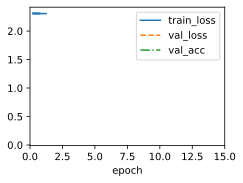

In [15]:
trainer = d2l.Trainer(max_epochs=15, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model = LeNet(lr=0.1)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model, data)

## Automatic training with lightning, transformers and W&B

The example that we have seen in the previous part of the notebook is a great way to learn about the basics of convolutional neural networks. In reality, however, you'll always start training your model from a more solid basis, such as a relatively recent CNN.

In this part of the notebook, we'll discuss how to train a CNN starting without having to code it from scratch, but rather using the pre-defined classes of the `transformers` library.

In addition to that, we'll make training automatic using `pytorch-lightning`. Doing so has two main benefits:
- it automates training, reducing the number of possible implementation mistakes
- it simplifies code, and allows you to scale to multiple gpus and multiple nodes.

### Using models from `transformers`

The transformers library from huggingface provides a huge number of pre-trained SOTA models, ranging from older CNNs to the more modern transformers.

In this part, we'll see how we can instantiate a ResNet-18 using the `transformers` library, without having to implement it from scratch. In addition to this, we'll see how to load pretrained weights, in order to leverage pre-existing knowledge and simplify training.

![](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/resnet_architecture.png)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


cats-image.py:   0%|          | 0.00/2.56k [00:00<?, ?B/s]

The repository for huggingface/cats-image contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/huggingface/cats-image.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating test split: 0 examples [00:00, ? examples/s]

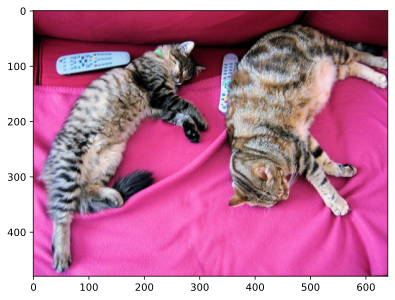

In [16]:
# load a toy dataset

from transformers import AutoFeatureExtractor, ResNetModel, ResNetForImageClassification
from datasets import load_dataset

dataset = load_dataset("huggingface/cats-image")
image = dataset["test"]["image"][0]

plt.imshow(image)

`transformers` is a very flexible library. It in fact allows to:
- instantiate a model that returns the final features, without the original classification head;
- instantiate the full model, with the classification head on top.

See https://huggingface.co/docs/transformers/v4.19.3/en/model_doc/resnet for a full documentation (other models behave similarly).

In [17]:
feature_extractor = AutoFeatureExtractor.from_pretrained("microsoft/resnet-50") #this module pre-processes images for us!
model = ResNetModel.from_pretrained("microsoft/resnet-50")

inputs = feature_extractor(image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

#let's inspect the outputs
for o in outputs:
  print(o)

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/models/convnext/feature_extraction_convnext.py:28: FutureWarning: The class ConvNextFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ConvNextImageProcessor instead.
  warnings.warn(


config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

last_hidden_state
pooler_output


In [18]:
# the first output is the output of the last hidden layer
print(outputs.last_hidden_state.shape ,"\n")

# the second is the output of the pooling
print(outputs.pooler_output.shape)

torch.Size([1, 2048, 7, 7]) 

torch.Size([1, 2048, 1, 1])


In [19]:
# we can also instantiate the full model

feature_extractor = AutoFeatureExtractor.from_pretrained("microsoft/resnet-50") #this module pre-processes images for us!
model = ResNetForImageClassification.from_pretrained("microsoft/resnet-50")

inputs = feature_extractor(image, return_tensors="pt")

with torch.no_grad():

    logits = model(**inputs).logits

# model predicts one of the 1000 ImageNet classes
predicted_label = logits.argmax(-1).item()
print(model.config.id2label[predicted_label])

tiger cat


### Upgrade the model to lightning

Now that we have a base model to work with, we can "upgrade" it to work with `pytorch lightning`.

Training a model with `pytorch-lightning` is very easy. At the core of the training, you just have to define your model extending the `lightning-module` class. Each subclass of this module must implement the following methods, besides `_init__`:
-  `training step`
-  `val step`
-  `test set`
-  `configure_optimizers`

Let's create a model with lightning!


In [30]:
import pytorch_lightning as pl

class LitResNet(pl.LightningModule):
  def __init__(self, backbone, num_classes):
    super().__init__()
    self.backbone = backbone
    self.num_classes = num_classes
    # we already know the output size from previous snippets, but it's always a good idea to make this parametric!
    self.lin = nn.Linear(2048, num_classes)
    self.loss_fn = nn.CrossEntropyLoss()

    # we need to freeze the backbone!
    for p in self.backbone.parameters():
      if p.requires_grad:
        p.requires_grad = False

    self.save_hyperparameters(ignore=["backbone"]) # save hyperparams for logging, ignoring of course the net!

  def training_step(self, batch, batch_idx):
    x, y = batch
    logits = self.shared_step(x)

    loss = self.loss_fn(logits, y)
    self.log("train/loss", loss)

    train_acc = (logits.argmax(1) == y).float().mean()
    self.log("train/acc", train_acc)
    return loss

  def validation_step(self, batch, batch_idx):
    x, y = batch
    logits = self.shared_step(x)

    loss = self.loss_fn(logits, y)
    self.log("val/loss", loss)

    val_acc = (logits.argmax(1) == y).float().mean()
    self.log("val/acc", val_acc)
    return loss

  def test_step(self, batch, batch_idx):
    x, y = batch
    logits = self.shared_step(x)

    accuracy = (logits.argmax(1) == y).float().mean()
    self.log("test_accuracy", accuracy)

  # it can be a good idea to define shared steps outside of the train/val/test methods!
  def shared_step(self, x):
    feats = self.backbone(x).pooler_output
    feats = feats.squeeze(-1).squeeze(-1)

    logits = self.lin(feats)
    return logits

  def configure_optimizers(self):
    # we only optimize the last layer's params
    return torch.optim.NAdam(self.lin.parameters(), lr=1e-5)
    # return torch.optim.NAdam(self.parameters(), lr=1e-3)

In [31]:
# let's now create our model and feed it to lightning

backbone = ResNetModel.from_pretrained("microsoft/resnet-50")
model = LitResNet(backbone, 10) #we'll test our model on CIFAR10

# print(model)

### Automatic training

Now that our model has been "upgraded" to lightning, we just need to create a dataset and feed it to lightning's automatic trainer. We'll use the same dataset from the previous notebook.

Files already downloaded and verified
Files already downloaded and verified


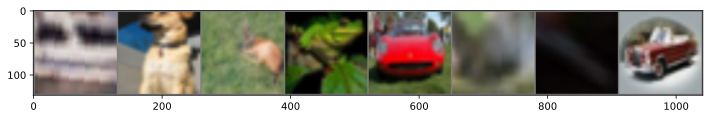

ship   dog    deer   frog   car    horse  bird   car    


In [27]:
import torchvision
import torchvision.transforms as T
from torchvision.datasets import CIFAR10

transforms = T.Compose([
  T.Resize(size=(128,128)),
   T.RandomApply(
       [T.RandomHorizontalFlip(),
       T.RandomVerticalFlip(),
       T.RandomGrayscale(),
       T.RandomRotation(degrees=(0, 360)),
       T.RandomResizedCrop(size=(128,128)),
       T.RandomSolarize(p=0.25, threshold=0.1)],
  p=0.5),
  T.ToTensor(),
  T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
]) #use Compose to concatenate multiple transforms

val_transforms = T.Compose([
  T.Resize(size=(128,128)),
  T.ToTensor(),
  T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transforms)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=val_transforms)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# to make loading data easier, we'll create a dataloader using
# torch.utils.data.Dataloader

batch_size = 512

trainset, valset = torch.utils.data.random_split(train_dataset, [45000, 5000])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

# let's visualize our data
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12,4))

# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images[:8]))
# print labels
print(''.join(f'{classes[labels[j]]:5s}  ' for j in range(8)))


In [23]:
# once we have a dataset, training with lightning is super easy.
# we simply need to instantiate a trainer, and it will take care of everything for us!

pl_trainer = pl.Trainer(max_epochs=10, accelerator="auto")
pl_trainer.fit(model, trainloader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name     | Type             | Params | Mode 
------------------------------------------------------
0 | backbone | ResNetModel      | 23.5 M | eval 
1 | lin      | Linear           | 20.5 K | train
2 | loss_fn  | CrossEntropyLoss | 0      | train
------------------------------------------------------
20.5 K    Trainable params
23.5 M    Non-trainable params
23.5 M    Total params
94.114    Total estimated model params size (MB)
2         Modules in train mode
282       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


In [24]:
# great! now we just need to test our network, in order to see how it performed!

pl_trainer.test(model, testloader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.8815000057220459     │
└───────────────────────────┴───────────────────────────┘

[{'test_accuracy': 0.8815000057220459}]

Mhh...that's...okay performance? Maybe we missed something!

### Logging with W&B

While training our model it is useful to visualize what's happening in order to understand whether everything is going smoothly. Looking at a loss function on a progress bar, however, is not ideal, so we might want to do something more eye-pleasing!

Thankfully, Weights&Biases allows us to do just so, providing automatic logging either standalone or with a pytorch lightning integration. Let's see how we can log the results of our test model and ensure that training is going on correctly!

In [28]:
import wandb
from pytorch_lightning.loggers import WandbLogger

wandb.init(
  project="cifar10_resnet",
  name="run_a",
  id="run_a"
)

wandb_logger = WandbLogger(log_model=True)

pl_trainer = pl.Trainer(max_epochs=20, accelerator="auto", logger=wandb_logger)
pl_trainer.fit(model, trainloader, val_loader)


wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


It seems our loss is moving around a bit too quickly. Let's try to fix this, and reduce the learning rate and train again. While we are at it, let's add some more augmentations!

Once our model is trained, pytorch lightning will automatically save the best checkpoint for us.

`pytorch-lightning` has many more functionalities that allow you to scale, automate and simplify training. A full list is available at: https://lightning.ai/docs/pytorch/stable/

<small> If you want to thinker further with your model and need more customizability, you might want to check https://lightning.ai/docs/fabric/stable/

In [29]:
#let's test again!
pl_trainer.test(model, testloader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.8754000067710876     │
└───────────────────────────┴───────────────────────────┘

[{'test_accuracy': 0.8754000067710876}]

## Optimizing a neural network 101

Source: https://github.com/google-research/tuning_playbook

This part of the notebook includes some concepts of the above playbook. It will come very handy when you work on your final projects, so I suggest to read the original guide as well!

Remember: you don't need to reinvent the wheel!

![](https://cdn.dribbble.com/users/480131/screenshots/5082274/media/bc38d9d209b4d6ffe26873a1da023106.gif)


### Reproducibility

The first step towards correctly optimizing a network is ensuring reproducibility. In other words, we want to minimize the random variables in our training to make experiments as comparable as possible.

Each library exposes utilities that improve reproducibility.
Let's see a few examples.

In [ ]:
# numpy
np.random.seed(42)

# pytorch
torch.manual_seed(42)

# lightning
pl.seed_everything(42)

### Choosing the model

Choose a **well established**, commonly used model architecture to get working first. It is always possible to build a custom model later.
Model architectures typically have various hyperparameters that determine the model's size and other details (e.g. number of layers, layer width, type of activation function).
Thus, **choosing the architecture really means choosing a family of different models** (one for each setting of the model hyperparameters).

When possible, **try to find a paper that tackles something as close as possible to the problem** at hand and reproduce that model as a starting point.
To reproduce results, try to use the original code (or be as faithful to it as possible), do not alter hyperparams, do not rewrite the code, etc...


### Choosing the optimizer

No optimizer is the "best" across all types of machine learning problems and model architectures. Even just comparing the performance of optimizers is a difficult task. 🤖

We recommend sticking with **well-established, popular optimizers**, especially when starting a new project.Ideally, choose the most popular optimizer used for the same type of problem.

Be prepared to give attention to **all** hyperparameters of the chosen optimizer. Optimizers with more hyperparameters may require more tuning effort to find the best configuration. This is particularly relevant in the beginning stages of a project when we are trying to find the best values of various other hyperparameters (e.g. architecture hyperparameters) while treating optimizer hyperparameters as nuisance parameters.
    
It may be preferable to **start with a simpler optimizer** (e.g. SGD with fixed momentum or Adam with fixed ϵ , β 1 , and β 2 ) in the initial stages of the project and switch to a more general optimizer later.

Well-established optimizers that we like include (but are not limited to):
  - **SGD with momentum** (we like the **Nesterov** variant)
  - **Adam and NAdam**. Note that Adam has 4 tunable hyperparameters and they can all matter!

### Choosing the batch size

The batch size is a key factor in determining the training time and computing resource consumption.
**Increasing the batch size will often reduce the training time**. This can be highly beneficial because it, e.g.:
- allows hyperparameters to be tuned more thoroughly within a fixed time interval, potentially resulting in a better final model.
- reduces the latency of the development cycle, allowing new ideas to be tested more frequently.

Increasing the batch size may either decrease, increase, or not change the resource consumption.
The **batch size should not be treated as a tunable hyperparameter** for validation set performance. As long as all hyperparameters are well-tuned (especially the learning rate and regularization hyperparameters) and the number of training steps is sufficient, **the same final performance should be attainable using any batch size** (see Shallue et al. 2018).

### Choosing the initial configuration

Before beginning hyperparameter tuning we must determine the starting point. This includes specifying:
1. the model configuration (e.g. number of layers)
2. the optimizer hyperparameters (e.g. learning rate)
3. the number of training steps.

Determining this initial configuration will require some manually configured training runs and trial-and-error.
Our guiding principle is to find a** simple, relatively fast, relatively low-resource-consumption configuration that obtains a "reasonable" result**.

"Simple" means **avoiding bells and whistles** wherever possible; these can always be added later. For example, start with a constant learning rate before adding fancy decay schedules.

"Reasonable" performance depends on the problem, but **at minimum means that the trained model performs much better than random chance on the validation set** (although it might be bad enough to not be worth deploying).



### Incremental tuning strategy


Our ultimate goal is to ***find a configuration that maximizes the performance of our model***. In some cases, our goal will be to maximize how much we can improve the model by a fixed deadline (e.g. submitting to a competition).
In other cases, we want to keep improving the model indefinitely (e.g. continually improving a model used in production).

In principle, we could maximize performance by using an algorithm to automatically search the entire space of possible configurations, but this is **not a practical nor feasible option**.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/6/6e/Complexity_subsets_pspace.svg/220px-Complexity_subsets_pspace.svg.png)

Most automated search algorithms rely on a hand-designed search space that defines the set of configurations to search in, and these search spaces can matter quite a bit (see gridsearch, genetic algorithms, etc).

The **most effective way to maximize performance is to start with a simple configuration and incrementally add features and make improvements while building up insight into the problem**.
We use automated search algorithms in each round of tuning and continually update our search spaces as our understanding grows.

At a high level, our incremental tuning strategy involves repeating the following four steps:
1. Identify an appropriately-scoped goal for the next round of experiments.
2. Design and run a set of experiments that makes progress towards this goal.
3. Learn what we can from the results.
4. Consider whether to launch the new best configuration.



### Closing words

Remember: **"Most of the time, our primary goal is to gain insight into the problem."**

All of the concepts we have just seen are useful tricks that you can use to increase performance and obtain better results. That said, you should always keep the above statement in mind.